In [1]:
import pandas as pd 

In [2]:
file_path = "../../data/43 at 0.2.xlsx"

In [4]:
df = pd.read_excel(file_path, sheet_name= "Detail_100_1_1")

In [5]:
df.head()

,Record Index,Status,JumpTo,Cycle,Step,Cur(mA),Voltage(V),CapaCity(mAh),Energy(mWh),Relative Time(h:min:s.ms),Absolute Time
0,1,Rest,1,1,1,0.0,1.3975,0.0,0.0,0:00:00.000,2022-03-03 13:13:17
1,2,Rest,1,1,1,0.0,1.3975,0.0,0.0,0:00:10.000,2022-03-03 13:13:27
2,3,Rest,1,1,1,0.0,1.3975,0.0,0.0,0:00:20.000,2022-03-03 13:13:37
3,4,Rest,1,1,1,0.0,1.3975,0.0,0.0,0:00:30.000,2022-03-03 13:13:47
4,5,Rest,1,1,1,0.0,1.3975,0.0,0.0,0:00:40.000,2022-03-03 13:13:57


In [22]:
# ok now first lets verigy data structure + data types + missing values

In [6]:
df.shape

(47089, 11)

In [7]:
df.columns

Index(['Record Index', 'Status', 'JumpTo', 'Cycle', 'Step', 'Cur(mA)',
       'Voltage(V)', 'CapaCity(mAh)', 'Energy(mWh)',
       'Relative Time(h:min:s.ms)', 'Absolute Time'],
      dtype='object')

In [8]:
df.dtypes

Record Index                          int64
Status                               object
JumpTo                                int64
Cycle                                 int64
Step                                  int64
Cur(mA)                             float64
Voltage(V)                          float64
CapaCity(mAh)                       float64
Energy(mWh)                         float64
Relative Time(h:min:s.ms)            object
Absolute Time                datetime64[ns]
dtype: object

In [9]:
df.isna().sum()

Record Index                 0
Status                       0
JumpTo                       0
Cycle                        0
Step                         0
Cur(mA)                      0
Voltage(V)                   0
CapaCity(mAh)                0
Energy(mWh)                  0
Relative Time(h:min:s.ms)    0
Absolute Time                0
dtype: int64

In [23]:
df_discharge =df[df["Status"] =="Discharge"]

In [11]:
df_discharge.head()

,Record Index,Status,JumpTo,Cycle,Step,Cur(mA),Voltage(V),CapaCity(mAh),Energy(mWh),Relative Time(h:min:s.ms),Absolute Time


In [24]:
# that means its empty so we will see what's the problem and we found out that neware doesn't write discharge it writes CC_DChg therefore now we will change the code
df["Status"].unique()

array(['Rest', 'CC_DChg', 'CC_Chg'], dtype=object)

In [15]:
df_discharge =df[df["Status"] =="CC_DChg"]

In [16]:
df_discharge.head

<bound method NDFrame.head of        Record Index   Status  JumpTo  Cycle  Step  Cur(mA)  Voltage(V)  \
2881           2882  CC_DChg       2      1     2  -0.4200      1.3281   
2882           2883  CC_DChg       2      1     2  -0.4200      1.2884   
2883           2884  CC_DChg       2      1     2  -0.4201      1.2558   
2884           2885  CC_DChg       2      1     2  -0.4200      1.2295   
2885           2886  CC_DChg       2      1     2  -0.4200      1.2072   
...             ...      ...     ...    ...   ...      ...         ...   
47068         47069  CC_DChg     126    794  3174  -0.4199      0.4532   
47075         47076  CC_DChg     131    795  3178  -0.4200      0.2132   
47076         47077  CC_DChg     131    795  3178  -0.4200      0.2132   
47083         47084  CC_DChg     136    796  3182  -0.4199      0.4262   
47084         47085  CC_DChg     136    796  3182  -0.4199      0.4262   

       CapaCity(mAh)  Energy(mWh) Relative Time(h:min:s.ms)  \
2881        0.0000

In [18]:
df_discharge.shape

(20172, 11)

In [19]:
df["Status"].unique()

array(['Rest', 'CC_DChg', 'CC_Chg'], dtype=object)

In [ ]:
# our data has many rows per cycle so we want grouping all rows belonging to same cycle grouped and shown as signgle row
# cycle1 -[row1, row2, row3,...]
# cycle2 -[row1, row2, row3,...]

In [ ]:
ok now grouped is an object now a DataFrame you can't see it like df.head()
grouped = df_discharge.groupby("Cycle")

In [ ]:
# yes now by doing len it is showing me basically there are 796 group packets created or in our words battery ran for 796 cycles
len(grouped)

796

In [26]:
# extracting max capacity per cycle because cycle 1 has many rows so we will typicaly select the one with max capacity
capacity_per_cycle = grouped["CapaCity(mAh)"].max()

In [27]:
capacity_per_cycle.head()

Cycle
1    0.074484
2    0.129494
3    0.137805
4    0.144777
5    0.151258
Name: CapaCity(mAh), dtype: float64

In [28]:
# lets convert to datafram
df_cycle = capacity_per_cycle.reset_index()
# this reset index will move index of cycle to normal coulmn

In [29]:
df_cycle.head()

,Cycle,CapaCity(mAh)
0,1,0.074484
1,2,0.129494
2,3,0.137805
3,4,0.144777
4,5,0.151258


In [31]:
#lets clean column name 
df_cycle.columns = ["cycle", "capacity_mAh"]

In [32]:
df_cycle.head()

,cycle,capacity_mAh
0,1,0.074484
1,2,0.129494
2,3,0.137805
3,4,0.144777
4,5,0.151258


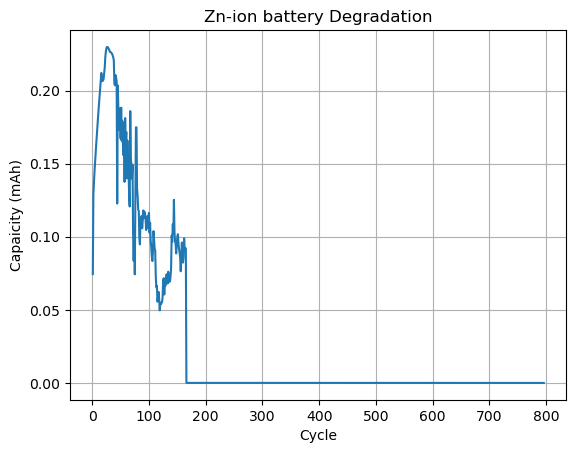

In [33]:
# lets plot degradation curve
import matplotlib.pyplot as plt 
plt.figure()
plt.plot(df_cycle["cycle"], df_cycle["capacity_mAh"])
plt.xlabel("Cycle")
plt.ylabel("Capaicity (mAh)")
plt.title("Zn-ion battery Degradation")
plt.grid(True)
plt.show()

In [42]:
df_cycle = df_cycle[df_cycle["capacity_mAh"] > 0.05]

In [43]:
df_cycle.tail()

,cycle,capacity_mAh
160,161,0.085854
161,162,0.098981
162,163,0.091034
163,164,0.092247
164,165,0.092095


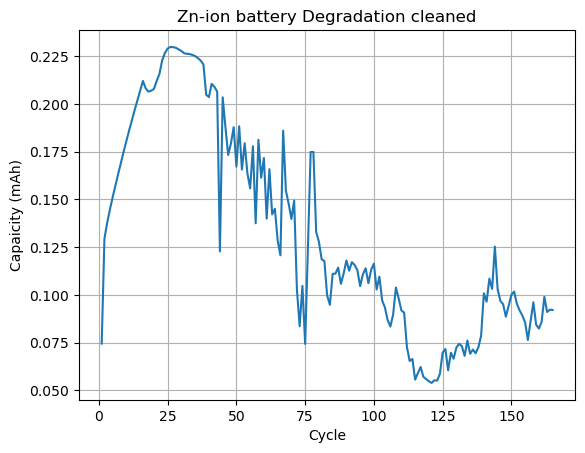

In [44]:
import matplotlib.pyplot as plt 
plt.figure()
plt.plot(df_cycle["cycle"], df_cycle["capacity_mAh"])
plt.xlabel("Cycle")
plt.ylabel("Capaicity (mAh)")
plt.title("Zn-ion battery Degradation cleaned")
plt.grid(True)
plt.show()

In [49]:
# now lets do feature engineering lets calculate capacity fade
initial_capacity = df_cycle["capacity_mAh"].iloc[0]

In [50]:
df_cycle["capacity_fade_percent"] = (
    (initial_capacity - df_cycle["capacity_mAh"])/ initial_capacity * 100
)

In [51]:
df_cycle.head()

,cycle,capacity_mAh,capacity_fade_percent
0,1,0.074484,0.000000
1,2,0.129494,-73.853377
2,3,0.137805,-85.012158
3,4,0.144777,-94.372352
4,5,0.151258,-103.073684


In [52]:
output_path = "../../data/week4_day1_cycle_data.csv"

In [53]:
df_cycle.to_csv(output_path, index=False)